Setup and metadata

In [1]:
# Analysis parameters
select_region = 'MOs'
block = 'aud'
window_bin_slice = slice(3, 9)                            # bins 3 to 8 = 0 to 0.5 s after onset
weight_threshold = 0.005
outcome_filter = 1 # 0 (all trials) or 1 (trials with licking)
n_neurons = 0

# Plot styles
color1 = 'magenta'
color2 = 'turquoise'
color3 = 'purple'
colormap = 'RdPu'

In [ ]:
import sys
sys.path.insert(0, '/code/src')

import pandas as pd 
import numpy as np
from datetime import datetime, date
import seaborn as sns
import pynwb
from matplotlib import pyplot as plt

import module
from module import get_binned_triggered_spike_counts_fast, neuron_psth, plot_confusion, get_stim_times
import importlib
importlib.reload(module)

from sklearn.svm import LinearSVC
from sklearn import svm
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import confusion_matrix

In [3]:
from aind_data_access_api.document_db import MetadataDbClient

API_GATEWAY_HOST = "api.allenneuraldynamics.org"
DATABASE = 'metadata_index'
COLLECTION = 'data_assets'

docdb_api_client = MetadataDbClient(
   host=API_GATEWAY_HOST,
    version="v2",
   database=DATABASE,
   collection=COLLECTION,
)
print(docdb_api_client._base_url)

https://api.allenneuraldynamics.org/v2/metadata_index/data_assets


In [4]:
aggregate = [
  {
    "$match": {
      "data_description.project_name": "Dynamic Routing", 
      "data_description.data_level": "derived", 
      "processing.data_processes": {
        "$elemMatch": {
          "process_type": "File format conversion",
          "start_date_time": {"$regex": "^2026-08-04"}
        }
      }
    }
  },
  {
    "$project": {
      "name": 1, 
      "subject_id": "$data_description.subject_id",
      "genotype": "$subject.subject_details.genotype", 
      "date_of_birth": "$subject.subject_details.date_of_birth", 
      "sex": "$subject.subject_details.sex",  
      "session_start_time": "$acquisition.acquisition_start_time",
      "session_end_time": "$acquisition.acquisition_end_time", 
      "stimulus_epochs": "$acquisition.stimulus_epochs",
      "project_name": "$data_description.project_name", 
      "modality": "$data_description.modalities.name", 
      "targeted_structure": "$acquisition.data_streams.configurations.probes.primary_targeted_structure.name" 
    }
  },
]
    
records = docdb_api_client.aggregate_docdb_records(pipeline=aggregate)

# Extract performance metrics in Python
for r in records:
    dr = next((e for e in r.get("stimulus_epochs", []) if e.get("stimulus_name") == "DynamicRouting1"), None)
    r["dr_performance"] = dr["performance_metrics"] if dr else None

In [5]:
df = pd.DataFrame(records)
df['session_date'] = df.apply(lambda x: datetime.fromisoformat(x['session_start_time']).date(), axis=1)
df['session_start_time'] = df.apply(lambda x: datetime.fromisoformat(x['session_start_time']).time(), axis=1)
df['session_end_time'] = df.apply(lambda x: datetime.fromisoformat(x['session_end_time']).time(), axis=1)
df['date_of_birth'] = df.apply(lambda x: datetime.strptime(x['date_of_birth'], '%Y-%m-%d').date(), axis=1)
df['age'] = df.apply(lambda x: (x['session_date'] - x['date_of_birth']).days, axis=1)

df['trials_total'] = df['dr_performance'].apply(lambda x: x['trials_total'] if x else None)
df['trials_rewarded'] = df['dr_performance'].apply(lambda x: x['trials_rewarded'] if x else None)
df['reward_rate'] = df['trials_rewarded'] / df['trials_total']
df['reward_consumed_mL'] = df['dr_performance'].apply(lambda x: x['reward_consumed_during_epoch'] if x else None)
df['block_metrics'] = df['dr_performance'].apply(lambda x: x['output_parameters']['block_metrics'] if x else None)
df['mean_dprime_same_modal'] = df['block_metrics'].apply(
    lambda x: pd.Series([b['dprime_same_modal'] for b in x.values()]).mean() if x else None
)
df['mean_dprime_other_modal'] = df['block_metrics'].apply(
    lambda x: pd.Series([b['dprime_other_modal_go'] for b in x.values()]).mean() if x else None
)

order = ['project_name', '_id', 'name', 'subject_id', 'genotype', 'date_of_birth', 'age', 'sex',
         'modality', 'session_date', 'session_start_time', 'session_end_time', 'targeted_structure',
         'trials_total', 'trials_rewarded', 'reward_rate', 'reward_consumed_mL',
         'mean_dprime_same_modal', 'mean_dprime_other_modal']
df = df[order].sort_values(by='subject_id')
df

,project_name,_id,name,subject_id,genotype,date_of_birth,age,sex,modality,session_date,session_start_time,session_end_time,targeted_structure,trials_total,trials_rewarded,reward_rate,reward_consumed_mL,mean_dprime_same_modal,mean_dprime_other_modal
2,Dynamic Routing,66dc0f20-45dc-4a65-ac3a-0a04ac0e1df4,ecephys_662892_2023-08-24_14-28-28_nwb_2026-08...,662892,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2022-12-24,243,Female,"[Extracellular electrophysiology, Behavior, Be...",2023-08-24,14:28:28,16:28:14.588745,"[[[Piriform area], [root]]]",476,123,0.258403,3.8400000000000016,2.152875,2.209537
6,Dynamic Routing,0f42545e-0e5f-4dfc-9777-8070c1e69ffd,ecephys_664851_2023-11-16_12-54-53_nwb_2026-08...,664851,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-01-09,311,Female,"[Extracellular electrophysiology, Behavior, Be...",2023-11-16,12:54:53,14:46:25.481437,"[[[Secondary motor area], [Field CA1], [Subicu...",527,139,0.263757,4.35,3.133879,2.593231
3,Dynamic Routing,468a63e1-6e2f-494e-8448-f8bf07afcad5,ecephys_667252_2023-09-28_15-00-38_nwb_2026-08...,667252,wt/wt,2023-01-27,244,Female,"[Extracellular electrophysiology, Behavior, Be...",2023-09-28,15:00:38,17:03:03.333877,"[[[Secondary motor area], [Primary motor area]...",486,123,0.253086,3.7800000000000002,3.261005,2.260717
10,Dynamic Routing,b0377871-8621-45b2-8c31-a3957d669787,ecephys_708016_2024-04-29_12-59-12_nwb_2026-08...,708016,Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-10-18,194,Male,"[Extracellular electrophysiology, Behavior, Be...",2024-04-29,12:59:12,15:00:31.755703,"[[[Secondary motor area], [Primary somatosenso...",533,129,0.242026,4.049999999999999,3.027970,2.665116
11,Dynamic Routing,ada82eb8-3f9c-4c80-9dbe-30b25114a391,ecephys_712815_2024-05-22_12-26-32_nwb_2026-08...,712815,wt/wt,2023-11-17,187,Female,"[Extracellular electrophysiology, Behavior, Be...",2024-05-22,12:26:32,14:23:25.111009,"[[[Dentate gyrus], [Posterior complex of the t...",545,138,0.253211,4.17,2.988601,1.745163
5,Dynamic Routing,1055573d-b0f0-4b31-a648-131ccddff1c8,ecephys_713655_2024-08-09_10-41-47_nwb_2026-08...,713655,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-11-23,260,Male,"[Extracellular electrophysiology, Behavior, Be...",2024-08-09,10:41:47,12:49:52.580059,"[[[Anterodorsal nucleus], [Supplemental somato...",515,129,0.250485,4.02,2.841083,3.002527
8,Dynamic Routing,6baeab62-02b8-4de7-8ca4-2ab5da7e0f20,ecephys_714748_2024-06-24_12-52-23_nwb_2026-08...,714748,Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-12-01,206,Male,"[Extracellular electrophysiology, Behavior, Be...",2024-06-24,12:52:23,14:59:27.907510,"[[[Supplemental somatosensory area], [Secondar...",550,134,0.243636,4.229999999999999,3.329563,2.693473
9,Dynamic Routing,5a958ba6-ebe7-400a-8021-3230170e6638,ecephys_715710_2024-07-16_12-58-34_nwb_2026-08...,715710,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-12-07,222,Male,"[Extracellular electrophysiology, Behavior, Be...",2024-07-16,12:58:34,15:05:31.280219,"[[[Supplemental somatosensory area], [Midbrain...",548,131,0.239051,4.049999999999999,2.032598,1.928238
7,Dynamic Routing,6774fb39-4c19-4ba2-99f5-2609fb1b9d77,ecephys_741137_2024-10-10_13-15-50_nwb_2026-08...,741137,wt/wt,2024-03-19,205,Male,"[Extracellular electrophysiology, Behavior, Be...",2024-10-10,13:15:50,15:19:11.275413,"[[[Retrosplenial area, dorsal part], [Suppleme...",543,124,0.228361,5.2,3.113432,2.623589
0,Dynamic Routing,c5bc8e0e-81ee-4e52-a7b6-90089b0dfc5f,ecephys_742903_2024-10-23_14-12-23_nwb_2026-08...,742903,Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2024-05-16,160,Female,"[Extracellular electrophysiology, Behavior, Be...",2024-10-23,14:12:23,16:15:54.652646,"[[[Primary somatosensory area], [Caudoputamen]...",489,124,0.253579,5.2,3.177007,2.342171


In [6]:
print(f'number of mice: {len(df)}')

number of mice: 12


In [7]:
file_path1 = df['name'][11]
file_path2 = file_path1[8:25]
nwb_path = '/data/dynamicrouting_datacube/' + file_path1 + '/' + file_path2 + '.nwb.zarr'

Dynamic routing data

In [8]:
# nwb_path = "/data/dynamicrouting_datacube/ecephys_759434_2025-02-04_12-27-22_nwb_2026-08-04_15-01-21/759434_2025-02-04.nwb.zarr"
nwbfile = pynwb.read_nwb(nwb_path)
nwbfile

/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (419933, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (419951, 500) float32 read-only>
  warnings.warn(


,timestamps
id,
0,NaN
1,14.14447
2,14.16114
3,14.17780
,timestamps
id,
0,NaN
1,14.36760
2,14.38426


In [9]:
all_units = nwbfile.units[:]
all_units

,activity_drift,amplitude,amplitude_cutoff,amplitude_cv_median,amplitude_cv_range,amplitude_median,ccf_ap,ccf_dv,ccf_ml,cluster_id,...,structure,sync_spike_2,sync_spike_4,sync_spike_8,unit_id,velocity_above,velocity_below,spike_times,obs_intervals,electrode_group
id,,,,,,,,,,,,,,,,,,,,,
0,0.327936,326.752960,0.000013,NaN,NaN,166.140000,8025.0,6025.0,5050.0,0,...,Mml,0.043464,0.000000,0.0,712815_2024-05-22_A-0,NaN,NaN,"[20.2106997775225, 20.33556603314869, 20.36423...","[[19.86740090760949, 7008.753194572321]]",probeA pynwb.ecephys.ElectrodeGroup at 0x14063...
1,0.242855,239.995033,0.000164,NaN,NaN,114.659996,8025.0,6025.0,5050.0,1,...,Mml,0.035217,0.000039,0.0,712815_2024-05-22_A-1,NaN,NaN,"[20.14543332570294, 20.550531992180538, 20.552...","[[19.86740090760949, 7008.753194572321]]",probeA pynwb.ecephys.ElectrodeGroup at 0x14063...
2,NaN,304.199989,NaN,NaN,NaN,201.239990,7650.0,4750.0,5050.0,2,...,MB,0.000000,0.000000,0.0,712815_2024-05-22_A-2,NaN,NaN,[251.6518045757292],"[[19.86740090760949, 7008.753194572321]]",probeA pynwb.ecephys.ElectrodeGroup at 0x14063...
3,0.052706,235.696236,NaN,NaN,NaN,121.679990,8025.0,6025.0,5050.0,3,...,Mml,0.028708,0.000000,0.0,712815_2024-05-22_A-3,NaN,NaN,"[19.951133965306497, 37.05874431635557, 63.564...","[[19.86740090760949, 7008.753194572321]]",probeA pynwb.ecephys.ElectrodeGroup at 0x14063...
4,NaN,197.599998,NaN,NaN,NaN,109.979996,8025.0,6025.0,5050.0,4,...,Mml,0.111111,0.000000,0.0,712815_2024-05-22_A-4,NaN,NaN,"[256.12452318556194, 284.1948641156576, 490.03...","[[19.86740090760949, 7008.753194572321]]",probeA pynwb.ecephys.ElectrodeGroup at 0x14063...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
906,0.242053,75.572648,0.001511,0.202541,0.188561,58.499996,5025.0,4400.0,4850.0,241,...,LSv,0.014176,0.000000,0.0,712815_2024-05-22_F-241,706.230499,NaN,"[23.684356608992857, 78.19082472735764, 127.69...","[[19.883570453948565, 7008.753312407092]]",probeF pynwb.ecephys.ElectrodeGroup at 0x14063...
907,0.064031,80.959301,0.000701,0.213331,0.258468,58.499996,4975.0,3500.0,4525.0,242,...,CP,0.019667,0.000000,0.0,712815_2024-05-22_F-242,698.677222,NaN,"[23.043892275317305, 30.284199234704545, 30.99...","[[19.883570453948565, 7008.753312407092]]",probeF pynwb.ecephys.ElectrodeGroup at 0x14063...
908,0.042118,54.765957,NaN,NaN,NaN,37.440000,4975.0,3500.0,4525.0,243,...,CP,0.042553,0.000000,0.0,712815_2024-05-22_F-243,NaN,NaN,"[210.63774226882612, 259.0709991764756, 260.60...","[[19.883570453948565, 7008.753312407092]]",probeF pynwb.ecephys.ElectrodeGroup at 0x14063...


In [10]:
# Combine and count the structure and default_qc columns to identify the number of good units in each brain structure. 

all_units.groupby("structure")["default_qc"].agg(passing="sum", total="count").sort_values("passing", ascending=False)

,passing,total
structure,,
CA1,20,87
CP,18,120
Eth,17,49
SSp,17,94
GPe,15,43
PO,12,87
LSv,12,36
DG,8,78
HY,8,26


In [11]:
units_table = nwbfile.units.to_dataframe()

Quality control

In [12]:
# QC thresholds
MAX_ISI_VIOLATIONS_RATIO = 0.5    # lower is better
MAX_AMPLITUDE_CUTOFF = 0.1        # lower is better
MIN_PRESENCE_RATIO = 0.95         # higher is better

good_units1 = units_table[
    (units_table.isi_violations_ratio < MAX_ISI_VIOLATIONS_RATIO) &
    (units_table.amplitude_cutoff < MAX_AMPLITUDE_CUTOFF) &
    (units_table.presence_ratio > MIN_PRESENCE_RATIO)
]
print('%d of %d units passed thresholded quality control' % (len(good_units1), len(units_table)))

# Default QC
good_units2 = units_table[
    (units_table.default_qc)
]

print('%d of %d units passed default quality control' % (len(good_units2), len(units_table)))

454 of 911 units passed thresholded quality control
174 of 911 units passed default quality control


In [13]:
# Find overlapping indices for two QC methods
shared_indices = good_units1.index.intersection(good_units2.index)

# Filter to get the overlapping rows
qc_units = units_table.loc[shared_indices]

print(f'{len(qc_units)} units overlap between both groups')

157 units overlap between both groups


0 good units in MOs


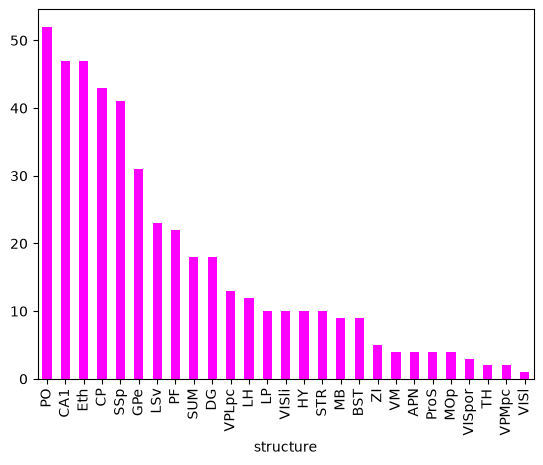

In [14]:
# qc_units.structure.value_counts().plot.bar(color=color1)
# region_units = qc_units[qc_units.structure == select_region]
good_units1.structure.value_counts().plot.bar(color=color1)
region_units = good_units1[good_units1.structure == select_region]

print(f'{len(region_units)} good units in {select_region}')

In [15]:
# Randomly select units based on n_neurons parameter
import random
random.seed(42)
rand_unit_ind = random.sample(range(len(region_units)), n_neurons)
random_units = region_units.iloc[rand_unit_ind]

Trial info

In [16]:
trials = nwbfile.trials.to_dataframe()
trials.head()

,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,...,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto,is_task_control_correct
id,,,,,,,,,,,,,,,,,,,,,
0,2150.37704,2155.88172,2150.37704,2151.84496,2151.905860,2152.406285,2151.96172,2152.87914,2152.61225,2152.60234,...,True,False,False,False,True,False,False,False,False,False
1,2157.33289,2162.83746,2157.33289,2158.80076,2158.861690,2159.362110,2158.91777,2159.83495,2159.40130,2159.39860,...,True,False,False,False,True,False,False,False,False,False
2,2163.55480,2169.05939,2163.55480,2165.02267,2165.083580,2165.584005,2165.13940,2166.05686,2165.48968,2165.47380,...,True,False,False,False,True,False,False,False,False,False
3,2173.64651,2179.15148,2173.64651,2175.11444,2175.175380,2175.675810,2175.23125,2176.14866,2175.59816,2175.59145,...,True,False,False,False,True,False,False,False,False,False
4,2179.20117,2184.70585,2179.20117,2180.66910,2180.730035,2181.230450,2180.78588,2181.70327,2181.16952,2181.15874,...,True,False,False,False,True,False,False,False,False,False


In [17]:
# rewarded and unrewarded target trial onsets (context fixed)
if block=='aud':
      rew_stim = 'sound1'
      unrew_stim = 'vis1'
elif block=='vis':
      rew_stim = 'vis1'
      unrew_stim = 'sound1'

if outcome_filter==0:
      # # option 1: no outcome filter
      rew_mask_all = get_stim_times(trials, rew_stim, block)
      unrew_mask = get_stim_times(trials, unrew_stim, block)
elif outcome_filter==1:
      # option 2: restrict to hits / false alarms
      rew_mask_all = get_stim_times(trials, rew_stim, block, 'is_hit')
      unrew_mask = get_stim_times(trials, unrew_stim, block, 'is_false_alarm')

print('visual-context trials: vis1 = %d, sound1 = %d'
      % (sum(rew_mask_all), sum(unrew_mask)))

visual-context trials: vis1 = 70, sound1 = 33


In [18]:
# Randomly select trials based on number of false alarms
true_indices = np.where(rew_mask_all)[0]
rand_trial_ind = np.random.choice(true_indices, size=15, replace=False)
rew_mask = np.zeros_like(rew_mask_all, dtype=bool)
rew_mask[rand_trial_ind] = True

In [19]:
rew_stim_times = trials.loc[rew_mask, 'stim_start_time'].values
unrew_stim_times = trials.loc[unrew_mask, 'stim_start_time'].values

Decode hit versus false alarm

In [20]:
# Build decoder
decode_bin_edge_array = np.arange(-0.3, 2.0, 0.1)          # 100 ms bin edges, -0.3 to 2.0 s

# pick trials: vis1 and vis2, visual context only
decode_trial_mask = rew_mask | unrew_mask
decode_stim_time_array = trials.loc[decode_trial_mask, 'stim_start_time'].values  # their onset times
decode_label_array = trials.loc[decode_trial_mask, 'stim_name'].values            # their stimulus labels (y)
print('%d visual-context trials go into the decoder' % len(decode_label_array))

# n_neurons = len(region_units)               # number of MOs neurons
# empty tensor: neurons x trials x time bins
population_tensor = np.zeros((n_neurons, len(decode_stim_time_array),
                              len(decode_bin_edge_array) - 1))
for neuron_row_index in range(n_neurons):                 # fill one neuron at a time
    population_tensor[neuron_row_index] = get_binned_triggered_spike_counts_fast(
        random_units.spike_times.values[neuron_row_index],
        decode_stim_time_array, decode_bin_edge_array)    # binned spike counts for this neuron

# sum spikes in that window -> one count per neuron per trial, then transpose to (trials, neurons)
population_count_array = np.sum(population_tensor[:, :, window_bin_slice], axis=2).T
print('input matrix shape (trials, neurons) = %s' % (population_count_array.shape,))

# safety check: one row per trial
assert population_count_array.shape[0] == len(decode_label_array), \
    'row count (%d) must equal number of trials (%d)' % (
        population_count_array.shape[0], len(decode_label_array))

48 visual-context trials go into the decoder
input matrix shape (trials, neurons) = (48, 0)


In [21]:
# Example of z-scored neural population activity used for decoding
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch

# sort trials by stimulus so vis1 and vis2 form two blocks
sort_order_array = np.argsort(decode_label_array)
sorted_zscore_array = StandardScaler().fit_transform(population_count_array)[sort_order_array]
sorted_label_array = decode_label_array[sort_order_array]

fig, ax = plt.subplots(1, 2, figsize=(11, 6),
                       gridspec_kw={'width_ratios': [1, 30]})

# left strip: stimulus of each trial (row)
stim_code_array = (sorted_label_array == unrew_stim).astype(int).reshape(-1, 1)
ax[0].imshow(stim_code_array, aspect='auto',
             cmap=plt.matplotlib.colors.ListedColormap([color1, color2]))
ax[0].set_xticks([])
ax[0].set_ylabel('trials (samples), sorted by stimulus')
ax[0].set_title('stimulus')

# right: the z-scored matrix
sns.heatmap(sorted_zscore_array, cmap=colormap, center=0, robust=True, ax=ax[1],
            cbar_kws={'label': 'z-scored spike count (per neuron)'})
ax[1].set_xlabel('neurons (features)')
ax[1].set_yticks([])
ax[1].set_title('decoder input, z-scored, trials grouped by stimulus')

fig.tight_layout()
legend_handle_list = [Patch(color=color1, label=rew_stim),
                      Patch(color=color2, label=unrew_stim)]
ax[0].legend(handles=legend_handle_list, title='stimulus',
             loc='upper left', bbox_to_anchor=(0, -0.02), frameon=False)

fig.tight_layout()
plt.show()

ValueError: Found array with 0 feature(s) (shape=(48, 0)) while a minimum of 1 is required by StandardScaler.

In [ ]:
# Train / test 
from sklearn.model_selection import cross_val_score, cross_val_predict

x_train, x_test, y_train, y_test = train_test_split(
    population_count_array, decode_label_array, random_state=0)
population_svc = LinearSVC(max_iter=5000)
population_svc.fit(x_train, y_train)
population_accuracy = population_svc.score(x_test, y_test)
print('population decoder is correct on %.0f%% of held-out trials'
      % (100 * population_accuracy))

# cross-validated score (5-fold)
population_cv_array = cross_val_score(
    LinearSVC(max_iter=5000), population_count_array, decode_label_array, cv=5)
print('population cross-validated accuracy: %.0f%% (folds %.0f to %.0f%%)'
      % (100 * population_cv_array.mean(),
         100 * population_cv_array.min(), 100 * population_cv_array.max()))

population decoder is correct on 100% of held-out trials
population cross-validated accuracy: 90% (folds 50 to 100%)


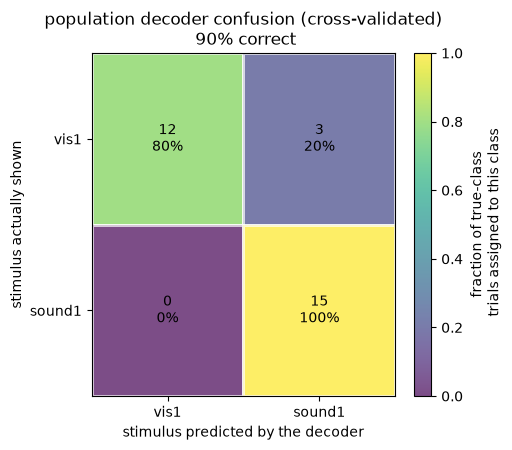

In [ ]:
# CROSS-VALIDATED population confusion matrix (not a single train/test split)
stim_name_array = np.array([rew_stim, unrew_stim])        # the two classes

population_cv_prediction_array = cross_val_predict(
    LinearSVC(max_iter=5000), population_count_array, decode_label_array, cv=5)
plot_confusion(decode_label_array, population_cv_prediction_array, stim_name_array,
               'population decoder confusion (cross-validated)\n %.0f%% correct'
               % (100 * population_cv_array.mean()))

Determine which neurons carry the decoder (feature importance)

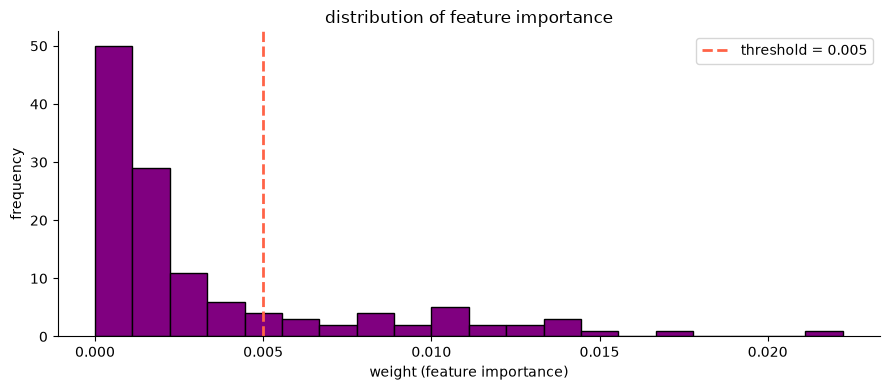

In [ ]:
# Histogram of decode weights
weight_array = np.abs(population_svc.coef_.ravel())

fig, ax = plt.subplots(figsize=(9, 4))
plt.hist(weight_array, bins=20, color=color3, edgecolor='black')
plt.axvline(x=weight_threshold, color='tomato', linestyle='--', linewidth=2, label = f"threshold = {weight_threshold}")
plt.legend()
ax.set_xlabel('weight (feature importance)')
ax.set_ylabel('frequency')
ax.set_title('distribution of feature importance')
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

In [ ]:
weighted_unit_ind = np.where(weight_array > weight_threshold)[0]
percent_weighted_units = int(len(weighted_unit_ind) / len(weight_array) * 100)
print(f"percent of units that pass threshold feature importance = {percent_weighted_units}%")

percent of units that pass threshold feature importance = 22%


In [138]:
# Get data for units with high feature importance 
weighted_units = random_units.iloc[weighted_unit_ind]

Plot neurons with high feature importance

In [ ]:
selective_units = [3, 6, 7, 10]
similar_units = [0, 2, 8, 12]

# PSTH time bins, -0.5 to 1.0 s around onset, 50 ms wide
psth_bin_edge_array = np.arange(-0.5, 1.0 + 0.05, 0.05)
psth_bin_center_array = psth_bin_edge_array[:-1] + 0.05 / 2

plt.rcParams.update({'font.size': 20}) 
fig, ax = plt.subplots(2, 4, figsize=(17, 7), sharex=True)
row_index_list = [selective_units, similar_units]
row_text_list = ['selective to vis1 vs aud1', 'similar for vis1 vs aud1']
for row in range(2):
    for col in range(4):
        neuron_row_index = row_index_list[row][col]
        single_ax = ax[row, col]
        single_ax.plot(psth_bin_center_array,
                       neuron_psth(random_units, neuron_row_index, rew_stim_times, psth_bin_edge_array),
                       color=color1, linewidth=2, label='vis1')
        single_ax.plot(psth_bin_center_array,
                       neuron_psth(random_units, neuron_row_index, unrew_stim_times, psth_bin_edge_array),
                       color=color2, linewidth=2, label='aud1')
        single_ax.axvline(0, color='0.5', linewidth=0.8)
        single_ax.set_title('neuron %d' % neuron_row_index)
        sns.despine(ax=single_ax)
    ax[row, 0].set_ylabel('firing rate\n(spikes / s)')
    ax[row, 0].annotate(row_text_list[row], xy=(-0.55, 1.18),
                        xycoords='axes fraction', fontweight='bold')
for single_ax in ax[-1, :]:
    single_ax.set_xlabel('time from stimulus onset \n (seconds)')
handle_list, label_list = ax[0, 0].get_legend_handles_labels()
fig.legend(handle_list, label_list, title='',
           loc='upper center', bbox_to_anchor=(0.5, 1.04), ncol=2, frameon=False)
fig.subplots_adjust(hspace=0.5, wspace=0.4)
fig.tight_layout()
plt.show()